In [1]:
import pandas as pd

# Load the IPC dataset
df = pd.read_csv("data raw/ipc_global_level1_long.csv")

# Convert date column
df["Date of analysis"] = pd.to_datetime(df["Date of analysis"], errors="coerce")

# Drop rows with missing or invalid dates
df = df.dropna(subset=["Date of analysis"])

# Group by country and find min/max analysis date
summary = (
    df.groupby("Country")["Date of analysis"]
      .agg(["min", "max", "nunique"])
      .reset_index()
      .sort_values("min")
)

# Add start / end year columns
summary["year_min"] = summary["min"].dt.year
summary["year_max"] = summary["max"].dt.year

# Flag countries that cover full 2017–2025 period
summary["has_2017_2025"] = (summary["year_min"] <= 2017) & (summary["year_max"] >= 2025)

# Print summary
print(summary.head(20))
print(f"\nTotal countries in file: {len(summary)}")
print(f"Countries with 2017–2025 coverage ({summary['has_2017_2025'].sum()} total):")
print(summary.loc[summary["has_2017_2025"], "Country"].tolist())


   Country        min        max  nunique  year_min  year_max  has_2017_2025
27     SSD 2017-01-01 2025-04-01       15      2017      2025           True
26     SOM 2017-01-01 2025-07-01       23      2017      2025           True
5      CAF 2017-02-01 2025-05-01       15      2017      2025           True
0      AFG 2017-05-01 2018-01-01        2      2017      2018          False
22     PAK 2017-05-01 2024-11-01        8      2017      2024          False
18     MOZ 2017-05-01 2025-06-01       14      2017      2025           True
16     MDG 2017-06-01 2025-07-01       16      2017      2025           True
30     TZA 2017-07-01 2022-10-01        2      2017      2022          False
13     HTI 2017-10-01 2025-09-01       13      2017      2025           True
7      COD 2018-06-01 2025-03-01       10      2018      2025          False
34     ZMB 2018-06-01 2025-08-01        9      2018      2025          False
31     UGA 2018-10-01 2025-06-01        4      2018      2025          False

C:\Users\migo8\AppData\Local\Temp\ipykernel_26336\296244838.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date of analysis"] = pd.to_datetime(df["Date of analysis"], errors="coerce")


In [2]:
# ======================================================
# validate_train_lagged_integrity.py
# ======================================================
# Purpose:
#   - Verify food price and lag completeness
#   - Ensure NaN values in lags only appear at sequence start
#   - Check label coverage and key uniqueness
#   - Inspect per-admin1 month counts
# ======================================================

import pandas as pd
from pathlib import Path

p = Path("data clean/train_features_2017_2025_lagged.csv")
df = pd.read_csv(p)
df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')

print(f"{p.name}: {len(df):,} rows × {len(df.columns)} cols")
print("Countries:", sorted(df['country'].unique().tolist()))

# ===== 1. Food base and lag NA rate =====
food = [c for c in ["beans_cowpea","maize","rice","veg_oil","wheat_flour"] if c in df.columns]
food_lags = [c for c in df.columns if any(c.startswith(f"{b}_lag") for b in food)]

if food:
    print("\nFood base NA%:")
    print((df[food].isna().mean() * 100).round(2).sort_index())

    print("\nFood lag NA% (expected NaN only at first few months):")
    print((df[food_lags].isna().mean() * 100).round(2).sort_values())

# ===== 2. Check NaN positions (should appear only at sequence start) =====
def head_na_ok(series):
    idx_na = series.index[series.isna()].tolist()
    return (len(idx_na) <= 3) and (idx_na == sorted(idx_na))

ok = True
for col in [c for c in food_lags if c.endswith("_lag3")]:
    bad = (
        df.sort_values('year_month')
          .groupby(['country','admin1_key'])[col]
          .apply(lambda s: not head_na_ok(s))
          .sum()
    )
    if bad > 0:
        ok = False
        print(f"{col}: {bad} sequences have unexpected NaN positions")
if ok:
    print("\nAll food lag NaNs only appear at the start of sequences (expected).")

# ===== 3. Horizon label coverage =====
for h in ["phase3plus_binary_20pct_h1","phase3plus_binary_20pct_h3"]:
    if h in df.columns:
        cov = 1 - df[h].isna().mean()
        print(f"{h} coverage: {cov:.2%}")

# ===== 4. Key uniqueness =====
dup = df.duplicated(subset=["country","admin1_key","year_month"]).sum()
print(f"\nDuplicate key rows: {dup}")

# ===== 5. Month count per admin1 =====
counts = (
    df.groupby(['country','admin1_key'])['year_month']
      .nunique().reset_index(name='months')
)
print("\nMonths per admin1 — summary:")
print(counts['months'].describe().to_string())

print("\nTop with fewest months (<100):")
print(counts.sort_values('months').head(8).to_string(index=False))


train_features_2017_2025_lagged.csv: 7,980 rows × 47 cols
Countries: ['CAF', 'MDG', 'MOZ', 'SOM', 'SSD']

Food base NA%:
beans_cowpea    0.0
maize           0.0
rice            0.0
veg_oil         0.0
dtype: float64

Food lag NA% (expected NaN only at first few months):
beans_cowpea_lag1    0.95
maize_lag1           0.95
rice_lag1            0.95
veg_oil_lag1         0.95
beans_cowpea_lag2    1.90
maize_lag2           1.90
rice_lag2            1.90
veg_oil_lag2         1.90
beans_cowpea_lag3    2.86
maize_lag3           2.86
rice_lag3            2.86
veg_oil_lag3         2.86
dtype: float64

All food lag NaNs only appear at the start of sequences (expected).
phase3plus_binary_20pct_h1 coverage: 100.00%
phase3plus_binary_20pct_h3 coverage: 100.00%

Duplicate key rows: 0

Months per admin1 — summary:
count     76.0
mean     105.0
std        0.0
min      105.0
25%      105.0
50%      105.0
75%      105.0
max      105.0

Top with fewest months (<100):
country       admin1_key  months
    C

=== Missing ratio by country ===
country  total_admin1  missing_admin1  missing_ratio
    CAF            29              28           0.97
    MDG             4               4           1.00
    MOZ            11              11           1.00
    SOM            18              18           1.00
    SSD            14              14           1.00

=== Missing ratio by feature group × country ===
country          CAF    MDG    MOZ   SOM    SSD
feature_group                                  
conflict       0.000  0.000  0.000  0.00  0.000
food           0.617  0.728  0.318  0.36  0.489
rain           0.000  0.000  0.000  0.00  0.000

Exported: data clean\missing_summary_by_country.csv
Exported: data clean\missing_ratio_by_feature.csv
Exported Excel: data clean\missing_analysis.xlsx


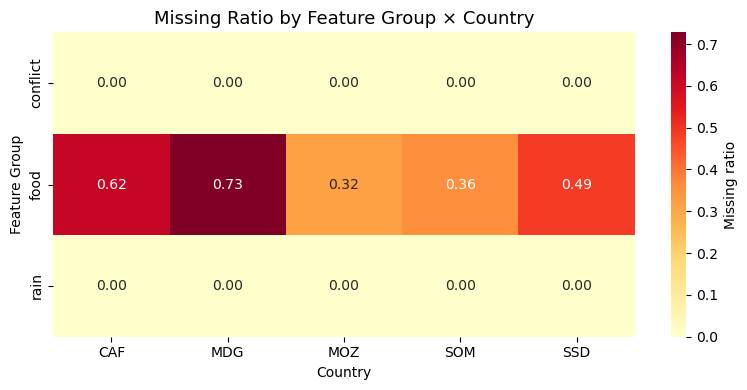

Heatmap saved: data clean\missing_ratio_heatmap.png


In [3]:
# ======================================================
# analyze_missing_features_full.py 
# Purpose:
#   1. Compute missing coverage by country and admin1
#   2. Analyze missing ratios by feature group (rain/conflict/food)
#   3. Export CSV and Excel reports
#   4. Visualize results as a heatmap
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ---------- Paths ----------
DATA_CLEAN = Path("data clean")
TRAIN_PATH = DATA_CLEAN / "train_features_2017_2025.csv"
MISS_PATH  = DATA_CLEAN / "feature_missing_admin1.csv"

# ---------- Load data ----------
df = pd.read_csv(TRAIN_PATH)
miss = pd.read_csv(MISS_PATH)

# ---------- 1) Country-level missing admin1 ratio ----------
stats = (
    df.groupby("country")["admin1"].nunique()
      .rename("total_admin1")
      .reset_index()
      .merge(
          miss.groupby("country")["admin1"].nunique()
              .rename("missing_admin1")
              .reset_index(),
          on="country", how="left"
      )
)
stats["missing_admin1"] = stats["missing_admin1"].fillna(0).astype(int)
stats["missing_ratio"] = (stats["missing_admin1"] / stats["total_admin1"]).round(2)

print("=== Missing ratio by country ===")
print(stats.to_string(index=False))

# ---------- 2) Missing ratio by feature group ----------
# Dynamically detect food-related features (columns that represent USD prices)
food_cols = [
    c for c in df.columns
    if c not in {
        "country", "admin1", "admin1_key", "join_key", "year_month",
        "phase3plus_binary_20pct", "affected_pct_3p", "affected_num_3p",
        "rain_mm", "conflict_events", "fatalities", "admin1_pop_est"
    }
]

feature_groups = {
    "rain": ["rain_mm"],
    "conflict": ["conflict_events", "fatalities"],
    "food": food_cols,
}

def missing_share(group, cols):
    """Compute mean missing ratio for a given group of columns."""
    if not cols:
        return np.nan
    valid = group[cols].isna().mean().mean()
    return round(valid, 3)

out = []
for c, sub in df.groupby("country"):
    for name, clist in feature_groups.items():
        out.append({
            "country": c,
            "feature_group": name,
            "missing_ratio": missing_share(sub, clist)
        })

detail = pd.DataFrame(out)
pivot = (
    detail.pivot(index="feature_group", columns="country", values="missing_ratio")
    .fillna(0)
    .round(3)
    .reindex(columns=sorted(df["country"].unique()))
)

print("\n=== Missing ratio by feature group × country ===")
print(pivot)

# ---------- 3) Export reports ----------
OUT_SUMMARY = DATA_CLEAN / "missing_summary_by_country.csv"
OUT_DETAIL  = DATA_CLEAN / "missing_ratio_by_feature.csv"
OUT_XLSX    = DATA_CLEAN / "missing_analysis.xlsx"

stats.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
detail.to_csv(OUT_DETAIL, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    stats.to_excel(writer, index=False, sheet_name="summary_by_country")
    detail.to_excel(writer, index=False, sheet_name="missing_by_feature")
    pivot.to_excel(writer, sheet_name="pivot_heatmap")

print(f"\nExported: {OUT_SUMMARY}")
print(f"Exported: {OUT_DETAIL}")
print(f"Exported Excel: {OUT_XLSX}")

# ---------- 4) Draw heatmap ----------
plt.figure(figsize=(8, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={'label': 'Missing ratio'}
)
plt.title("Missing Ratio by Feature Group × Country", fontsize=13)
plt.xlabel("Country")
plt.ylabel("Feature Group")
plt.tight_layout()

OUT_FIG = DATA_CLEAN / "missing_ratio_heatmap.png"
plt.savefig(OUT_FIG, dpi=300)
plt.show()

print(f"Heatmap saved: {OUT_FIG}")


In [4]:
# ======================================================
# validate_train_lagged_integrity.py
# ======================================================
# Purpose:
#   - Verify food price and lag completeness
#   - Ensure NaN values in lags only appear at sequence start
#   - Check label coverage and key uniqueness
#   - Inspect per-admin1 month counts
# ======================================================

import pandas as pd
from pathlib import Path

p = Path("data clean/train_features_2017_2025_lagged.csv")
df = pd.read_csv(p)
df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')

print(f"{p.name}: {len(df):,} rows × {len(df.columns)} cols")
print("Countries:", sorted(df['country'].unique().tolist()))

# ===== 1. Food base and lag NA rate =====
food = [c for c in ["beans_cowpea","maize","rice","veg_oil","wheat_flour"] if c in df.columns]
food_lags = [c for c in df.columns if any(c.startswith(f"{b}_lag") for b in food)]

if food:
    print("\nFood base NA%:")
    print((df[food].isna().mean() * 100).round(2).sort_index())

    print("\nFood lag NA% (expected NaN only at first few months):")
    print((df[food_lags].isna().mean() * 100).round(2).sort_values())

# ===== 2. Check NaN positions (should appear only at sequence start) =====
def head_na_ok(series):
    idx_na = series.index[series.isna()].tolist()
    return (len(idx_na) <= 3) and (idx_na == sorted(idx_na))

ok = True
for col in [c for c in food_lags if c.endswith("_lag3")]:
    bad = (
        df.sort_values('year_month')
          .groupby(['country','admin1_key'])[col]
          .apply(lambda s: not head_na_ok(s))
          .sum()
    )
    if bad > 0:
        ok = False
        print(f"{col}: {bad} sequences have unexpected NaN positions")
if ok:
    print("\nAll food lag NaNs only appear at the start of sequences (expected).")

# ===== 3. Horizon label coverage =====
for h in ["phase3plus_binary_20pct_h1","phase3plus_binary_20pct_h3"]:
    if h in df.columns:
        cov = 1 - df[h].isna().mean()
        print(f"{h} coverage: {cov:.2%}")

# ===== 4. Key uniqueness =====
dup = df.duplicated(subset=["country","admin1_key","year_month"]).sum()
print(f"\nDuplicate key rows: {dup}")

# ===== 5. Month count per admin1 =====
counts = (
    df.groupby(['country','admin1_key'])['year_month']
      .nunique().reset_index(name='months')
)
print("\nMonths per admin1 — summary:")
print(counts['months'].describe().to_string())

print("\nTop with fewest months (<100):")
print(counts.sort_values('months').head(8).to_string(index=False))


train_features_2017_2025_lagged.csv: 7,980 rows × 47 cols
Countries: ['CAF', 'MDG', 'MOZ', 'SOM', 'SSD']

Food base NA%:
beans_cowpea    0.0
maize           0.0
rice            0.0
veg_oil         0.0
dtype: float64

Food lag NA% (expected NaN only at first few months):
beans_cowpea_lag1    0.95
maize_lag1           0.95
rice_lag1            0.95
veg_oil_lag1         0.95
beans_cowpea_lag2    1.90
maize_lag2           1.90
rice_lag2            1.90
veg_oil_lag2         1.90
beans_cowpea_lag3    2.86
maize_lag3           2.86
rice_lag3            2.86
veg_oil_lag3         2.86
dtype: float64

All food lag NaNs only appear at the start of sequences (expected).
phase3plus_binary_20pct_h1 coverage: 100.00%
phase3plus_binary_20pct_h3 coverage: 100.00%

Duplicate key rows: 0

Months per admin1 — summary:
count     76.0
mean     105.0
std        0.0
min      105.0
25%      105.0
50%      105.0
75%      105.0
max      105.0

Top with fewest months (<100):
country       admin1_key  months
    C

In [5]:
import sys
print(sys.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]
